# Yield Models and Visualization

This notebook is the Python version of the long-term model workflow style in `longterm_experiment_models.Rmd`.
It shows:

1. Data preprocessing
2. Distribution plots
3. Mean plus standard-error plots
4. Mixed-effects model term tests
5. Regression-style fitted mean plots
6. Residual diagnostics

The notebook uses project-relative paths only.


## 1) Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display
from patsy import dmatrix
from scipy import stats

ROOT = Path.cwd().resolve()
if not (ROOT / 'cleaned_data').exists() and (ROOT.parent / 'cleaned_data').exists():
    ROOT = ROOT.parent


def relpath(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


CLEAN_DIR = ROOT / 'cleaned_data'
RESULT_DIR = ROOT / 'results' / 'yield'
FIG_DIR = RESULT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LT_PATH = CLEAN_DIR / 'longterm_yield_analysis_locked.csv'
ACUTE_PATH = CLEAN_DIR / 'acute_yield_analysis_locked.csv'

OUTCOMES = ['healthy_weight_g', 'pct_rotten_count', 'pct_rotten_weight']
OUTCOME_LABELS = {
    'healthy_weight_g': 'Healthy Fruit Weight (g)',
    'pct_rotten_count': 'Rotten Fruit Proportion (count)',
    'pct_rotten_weight': 'Rotten Fruit Proportion (weight)',
}
CULTIVAR_ORDER = ['MQ', 'St']
HEAT_LEVEL_ORDER = ['A', 'B', 'C', 'D']
LONGTERM_TREATMENT_ORDER = ['Control', 'OTC']
ACUTE_CONDITION_ORDER = [0, 1]
CULTIVAR_COLORS = {'MQ': '#d95f02', 'St': '#1b9e77'}
CONDITION_COLORS = {0: '#d62728', 1: '#1f77b4'}
CONDITION_LABELS = {0: 'Heated', 1: 'Control'}

print('Project root detected.')
print(f'- {relpath(LT_PATH)} | exists={LT_PATH.exists()}')
print(f'- {relpath(ACUTE_PATH)} | exists={ACUTE_PATH.exists()}')


Project root detected.
- cleaned_data/longterm_yield_analysis_locked.csv | exists=True
- cleaned_data/acute_yield_analysis_locked.csv | exists=True


## 2) Data preprocessing

In [2]:
lt = pd.read_csv(LT_PATH)
acute = pd.read_csv(ACUTE_PATH)

lt['include_in_yield_model'] = lt['include_in_yield_model'].astype(int)
acute['include_in_yield_model'] = acute['include_in_yield_model'].astype(int)
acute['is_control'] = acute['is_control'].astype(int)

lt_keep = lt[lt['include_in_yield_model'] == 1].copy()
acute_keep = acute[acute['include_in_yield_model'] == 1].copy()

lt_keep['heat_trt'] = pd.Categorical(lt_keep['heat_trt'], categories=LONGTERM_TREATMENT_ORDER, ordered=True)
lt_keep['cultivar'] = pd.Categorical(lt_keep['cultivar'], categories=CULTIVAR_ORDER, ordered=True)
acute_keep['heat_level'] = pd.Categorical(acute_keep['heat_level'], categories=HEAT_LEVEL_ORDER, ordered=True)
acute_keep['cultivar'] = pd.Categorical(acute_keep['cultivar'], categories=CULTIVAR_ORDER, ordered=True)

lt_keep['set_key'] = lt_keep['cultivar'].astype(str) + '_' + lt_keep['set_id'].astype(str)
acute_keep['pair_id'] = (
    acute_keep['cultivar'].astype(str)
    + '_'
    + acute_keep['heat_level'].astype(str)
    + '_'
    + acute_keep['replicate'].astype(str)
)

print('Long-term rows kept for yield model:', len(lt_keep))
print('Acute rows kept for yield model:', len(acute_keep))

lt_keep.head()


Long-term rows kept for yield model: 16
Acute rows kept for yield model: 48


,experiment,source_row,cultivar,heat_trt,is_control,set_id,plot_id,paired_plot_id,rotten_count,rotten_weight_g,...,total_count,total_weight_g,pct_rotten_count,pct_rotten_weight,include_in_yield_model,include_in_temp_model,sensor_missing_overview,sensor_missing_files,dataset_lock_version,set_key
0,longterm,20,MQ,OTC,0,11,9,13,21,21.74,...,484,987.20,0.043388,0.022022,1,1,0,0,v1_2026-03-05,MQ_11
1,longterm,13,MQ,OTC,0,12,10,14,11,13.79,...,459,901.35,0.023965,0.015299,1,1,0,0,v1_2026-03-05,MQ_12
2,longterm,18,MQ,OTC,0,13,11,15,29,45.15,...,393,738.77,0.073791,0.061115,1,1,0,0,v1_2026-03-05,MQ_13
3,longterm,19,MQ,OTC,0,14,12,16,23,14.44,...,425,808.15,0.054118,0.017868,1,1,0,0,v1_2026-03-05,MQ_14
4,longterm,16,MQ,Control,1,11,13,9,35,54.15,...,484,977.11,0.072314,0.055419,1,1,0,0,v1_2026-03-05,MQ_11


In [3]:
def mean_se_frame(df: pd.DataFrame, group_cols: list[str], outcome: str) -> pd.DataFrame:
    out = (
        df.groupby(group_cols, observed=False)[outcome]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    out['se'] = out['std'] / np.sqrt(out['count'])
    out['ci_low'] = out['mean'] - 1.96 * out['se']
    out['ci_high'] = out['mean'] + 1.96 * out['se']
    out['outcome'] = outcome
    return out


def fit_mixedlm(formula: str, data: pd.DataFrame, group_col: str):
    methods = ['lbfgs', 'powell', 'cg', 'nm']
    fallback = None
    errors = []
    for method in methods:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = smf.mixedlm(formula, data=data, groups=data[group_col]).fit(
                    reml=False,
                    method=method,
                    maxiter=1000,
                    disp=False,
                )
            if model.converged:
                return model, method
            if fallback is None:
                fallback = (model, method)
        except Exception as exc:
            errors.append(f'{method}: {exc}')
    if fallback is not None:
        return fallback
    raise RuntimeError('MixedLM failed for all optimizers: ' + ' | '.join(errors))


def fixed_effect_predictions(model, grid: pd.DataFrame) -> pd.DataFrame:
    fe_names = model.fe_params.index.tolist()
    X = dmatrix(model.model.data.design_info, grid, return_type='dataframe')
    X = X[fe_names]
    beta = model.fe_params.loc[fe_names].to_numpy()
    cov = model.cov_params().loc[fe_names, fe_names].to_numpy()
    xmat = X.to_numpy()
    pred = xmat @ beta
    se = np.sqrt(np.einsum('ij,jk,ik->i', xmat, cov, xmat))
    out = grid.copy()
    out['pred'] = pred
    out['se'] = se
    out['ci_low'] = pred - 1.96 * se
    out['ci_high'] = pred + 1.96 * se
    return out


def mixedlm_wald_terms_table(model, outcome: str) -> pd.DataFrame:
    table = model.wald_test_terms(skip_single=False).table.reset_index().rename(columns={'index': 'term'})
    p_col = 'pvalue' if 'pvalue' in table.columns else 'p_value'
    return pd.DataFrame(
        {
            'outcome': outcome,
            'term': table['term'],
            'statistic': table['statistic'].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
            'df_constraint': table['df_constraint'].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
            'p_value': table[p_col].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
        }
    )


def diagnostic_figure(model, title_prefix: str):
    fitted = np.asarray(model.fittedvalues)
    resid = np.asarray(model.resid)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(fitted, resid, color='darkblue', alpha=0.8)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_title(f'{title_prefix}: Residuals vs Fitted')
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(alpha=0.2)

    stats.probplot(resid, dist='norm', plot=axes[1])
    axes[1].set_title(f'{title_prefix}: QQ Plot')
    axes[1].grid(alpha=0.2)
    fig.tight_layout()
    return fig


## 3) Long-term visualization

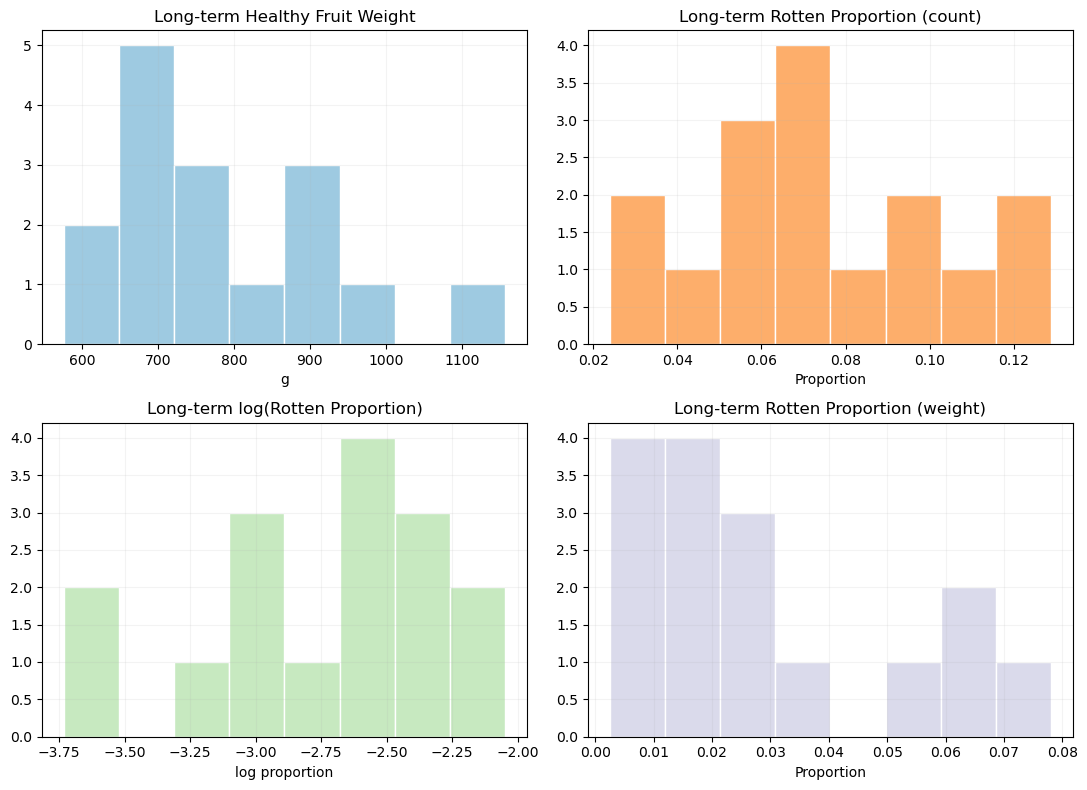

In [4]:
fig_dist, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

axes[0].hist(lt_keep['healthy_weight_g'].dropna(), bins=8, color='#9ecae1', edgecolor='white')
axes[0].set_title('Long-term Healthy Fruit Weight')
axes[0].set_xlabel('g')

axes[1].hist(lt_keep['pct_rotten_count'].dropna(), bins=8, color='#fdae6b', edgecolor='white')
axes[1].set_title('Long-term Rotten Proportion (count)')
axes[1].set_xlabel('Proportion')

axes[2].hist(np.log(np.clip(lt_keep['pct_rotten_count'].dropna(), 1e-6, None)), bins=8, color='#c7e9c0', edgecolor='white')
axes[2].set_title('Long-term log(Rotten Proportion)')
axes[2].set_xlabel('log proportion')

axes[3].hist(lt_keep['pct_rotten_weight'].dropna(), bins=8, color='#dadaeb', edgecolor='white')
axes[3].set_title('Long-term Rotten Proportion (weight)')
axes[3].set_xlabel('Proportion')

for ax in axes:
    ax.grid(alpha=0.15)

fig_dist.tight_layout()
fig_dist_path = FIG_DIR / 'yield_longterm_distributions.png'
fig_dist.savefig(fig_dist_path, dpi=180, bbox_inches='tight')
plt.show()


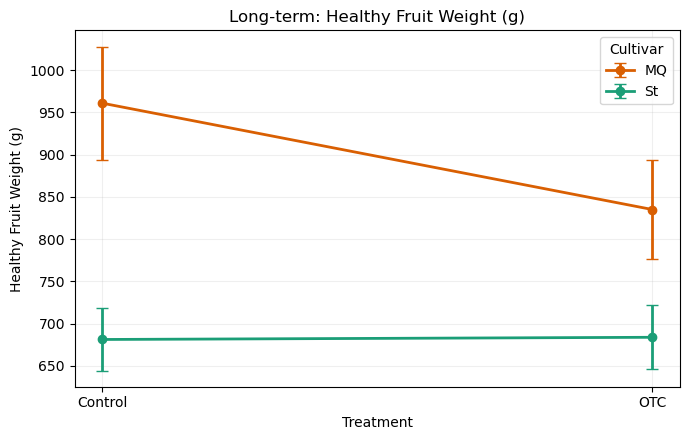

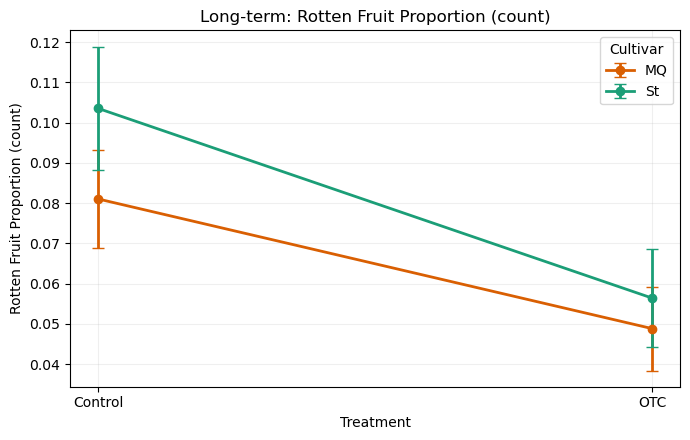

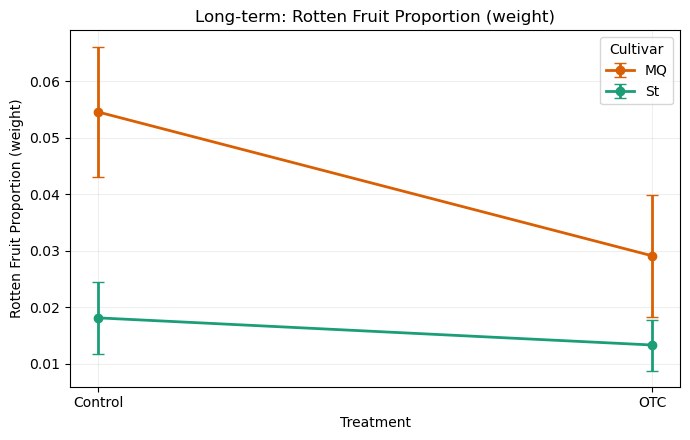

In [5]:
def plot_longterm_mean_se(outcome: str, filename: str):
    summary = mean_se_frame(lt_keep, ['cultivar', 'heat_trt'], outcome)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for cultivar in CULTIVAR_ORDER:
        sub = summary[summary['cultivar'] == cultivar].copy()
        sub['heat_trt'] = pd.Categorical(sub['heat_trt'], categories=LONGTERM_TREATMENT_ORDER, ordered=True)
        sub = sub.sort_values('heat_trt')
        x = np.arange(len(sub))
        ax.errorbar(
            x,
            sub['mean'],
            yerr=sub['se'],
            marker='o',
            linewidth=2,
            capsize=4,
            color=CULTIVAR_COLORS[cultivar],
            label=cultivar,
        )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(LONGTERM_TREATMENT_ORDER)
    ax.set_xlabel('Treatment')
    ax.set_ylabel(OUTCOME_LABELS[outcome])
    ax.set_title(f'Long-term: {OUTCOME_LABELS[outcome]}')
    ax.legend(title='Cultivar', loc='best')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig_path = FIG_DIR / filename
    fig.savefig(fig_path, dpi=180, bbox_inches='tight')
    plt.show()
    return fig_path

fig_lt_hw = plot_longterm_mean_se('healthy_weight_g', 'yield_longterm_healthy_weight_mean_se.png')
fig_lt_rc = plot_longterm_mean_se('pct_rotten_count', 'yield_longterm_rotten_count_mean_se.png')
fig_lt_rw = plot_longterm_mean_se('pct_rotten_weight', 'yield_longterm_rotten_weight_mean_se.png')


## 4) Long-term models and ANOVA-style tests

In [6]:
lt_models = {}
lt_wald_tables = []
for outcome in OUTCOMES:
    model, optimizer = fit_mixedlm(f'{outcome} ~ C(cultivar) * C(heat_trt)', lt_keep, 'set_key')
    lt_models[outcome] = model
    table = mixedlm_wald_terms_table(model, outcome)
    table.insert(0, 'optimizer', optimizer)
    lt_wald_tables.append(table)

lt_wald = pd.concat(lt_wald_tables, ignore_index=True)
print('Long-term Wald term tests (Python analogue of ANOVA)')
display(lt_wald)


Long-term Wald term tests (Python analogue of ANOVA)


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn

,optimizer,outcome,term,statistic,df_constraint,p_value
0,lbfgs,healthy_weight_g,Intercept,447.014499,1.0,3.219941e-99
1,lbfgs,healthy_weight_g,C(cultivar),18.932774,1.0,1.354064e-05
2,lbfgs,healthy_weight_g,C(heat_trt),4.111836,1.0,4.258412e-02
3,lbfgs,healthy_weight_g,C(cultivar):C(heat_trt),2.141201,1.0,1.433896e-01
4,lbfgs,pct_rotten_count,Intercept,54.884404,1.0,1.278314e-13
5,lbfgs,pct_rotten_count,C(cultivar),2.115172,1.0,1.458456e-01
6,lbfgs,pct_rotten_count,C(heat_trt),4.337525,1.0,3.728109e-02
7,lbfgs,pct_rotten_count,C(cultivar):C(heat_trt),0.465263,1.0,4.951744e-01
8,lbfgs,pct_rotten_weight,Intercept,50.903637,1.0,9.701367e-13
9,lbfgs,pct_rotten_weight,C(cultivar),11.374381,1.0,7.446402e-04


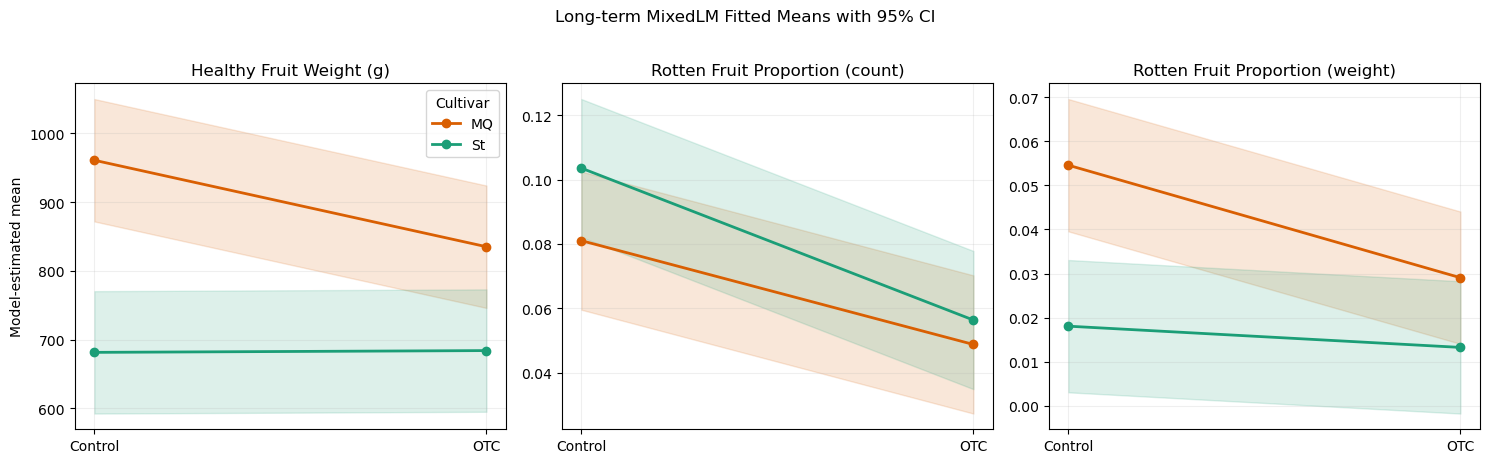

In [7]:
longterm_grid = pd.DataFrame(
    [
        {'cultivar': cultivar, 'heat_trt': heat_trt, 'outcome': outcome}
        for outcome in OUTCOMES
        for cultivar in CULTIVAR_ORDER
        for heat_trt in LONGTERM_TREATMENT_ORDER
    ]
)

lt_pred_frames = []
for outcome in OUTCOMES:
    grid = longterm_grid[longterm_grid['outcome'] == outcome][['cultivar', 'heat_trt']].copy()
    pred = fixed_effect_predictions(lt_models[outcome], grid)
    pred['outcome'] = outcome
    lt_pred_frames.append(pred)
lt_pred = pd.concat(lt_pred_frames, ignore_index=True)

fig_lt_pred, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, outcome in zip(axes, OUTCOMES):
    sub = lt_pred[lt_pred['outcome'] == outcome].copy()
    for cultivar in CULTIVAR_ORDER:
        curve = sub[sub['cultivar'] == cultivar].copy()
        curve['heat_trt'] = pd.Categorical(curve['heat_trt'], categories=LONGTERM_TREATMENT_ORDER, ordered=True)
        curve = curve.sort_values('heat_trt')
        x = np.arange(len(curve))
        ax.plot(x, curve['pred'], marker='o', linewidth=2, color=CULTIVAR_COLORS[cultivar], label=cultivar)
        ax.fill_between(x, curve['ci_low'], curve['ci_high'], color=CULTIVAR_COLORS[cultivar], alpha=0.15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(LONGTERM_TREATMENT_ORDER)
    ax.set_title(OUTCOME_LABELS[outcome])
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Model-estimated mean')
axes[0].legend(title='Cultivar')
fig_lt_pred.suptitle('Long-term MixedLM Fitted Means with 95% CI', y=1.02)
fig_lt_pred.tight_layout()
fig_lt_pred_path = FIG_DIR / 'yield_longterm_mixedlm_fitted_means.png'
fig_lt_pred.savefig(fig_lt_pred_path, dpi=180, bbox_inches='tight')
plt.show()


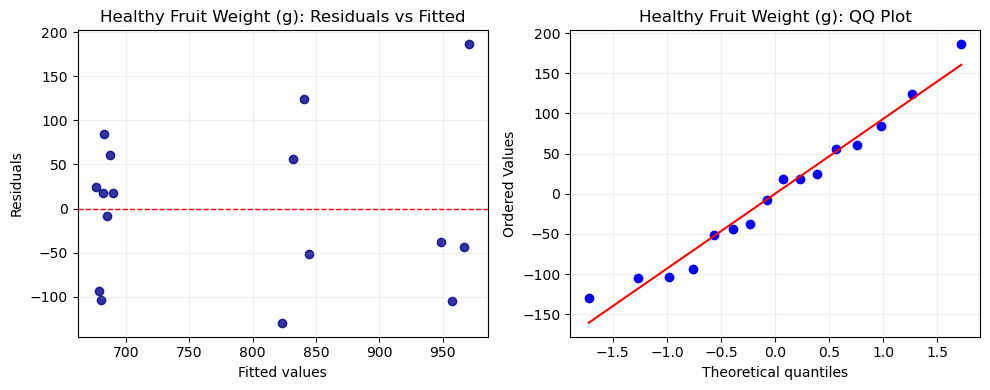

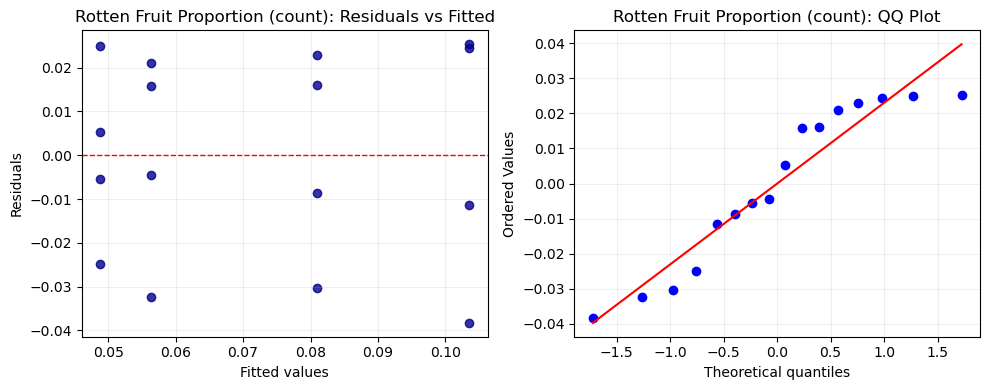

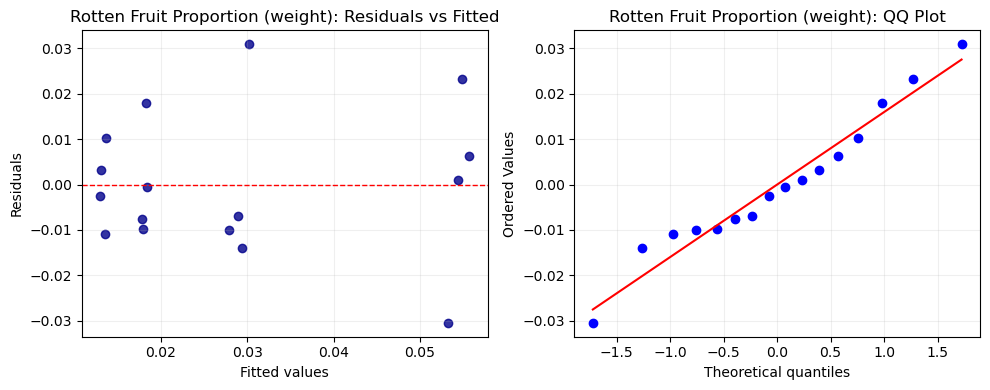

In [8]:
diag_paths_lt = []
for outcome in OUTCOMES:
    title = OUTCOME_LABELS[outcome]
    fig = diagnostic_figure(lt_models[outcome], title)
    out_path = FIG_DIR / f'yield_longterm_diagnostics_{outcome}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    diag_paths_lt.append(out_path)
    plt.show()


## 5) Acute visualization

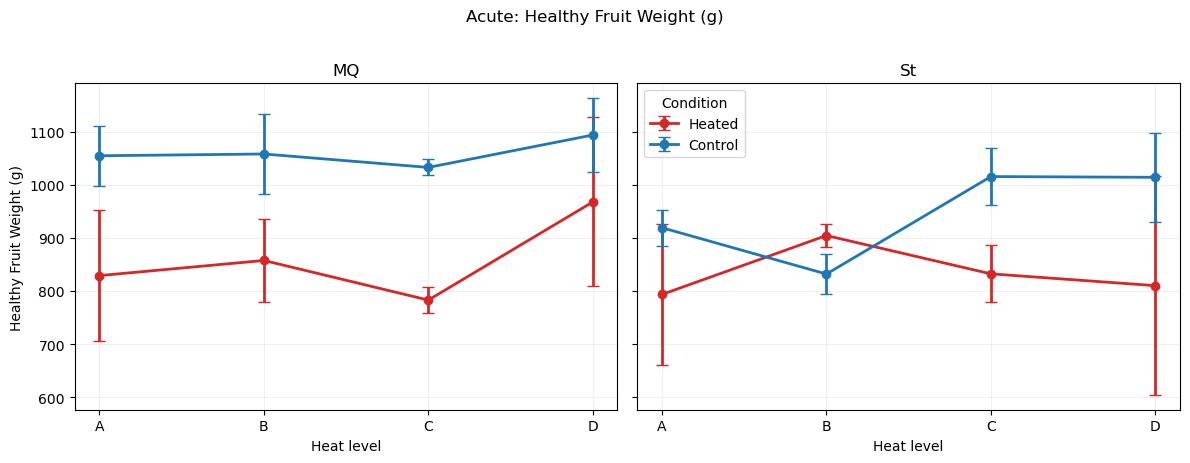

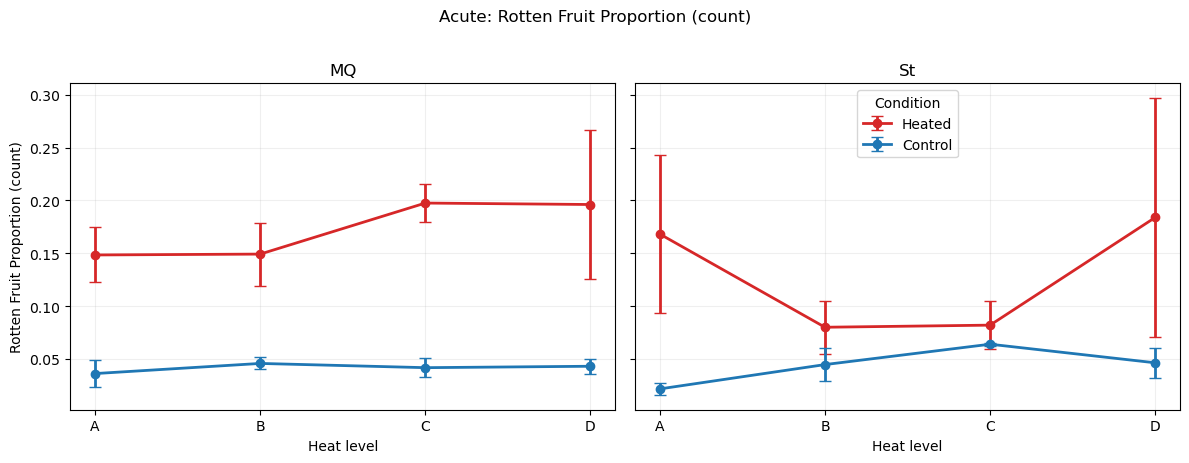

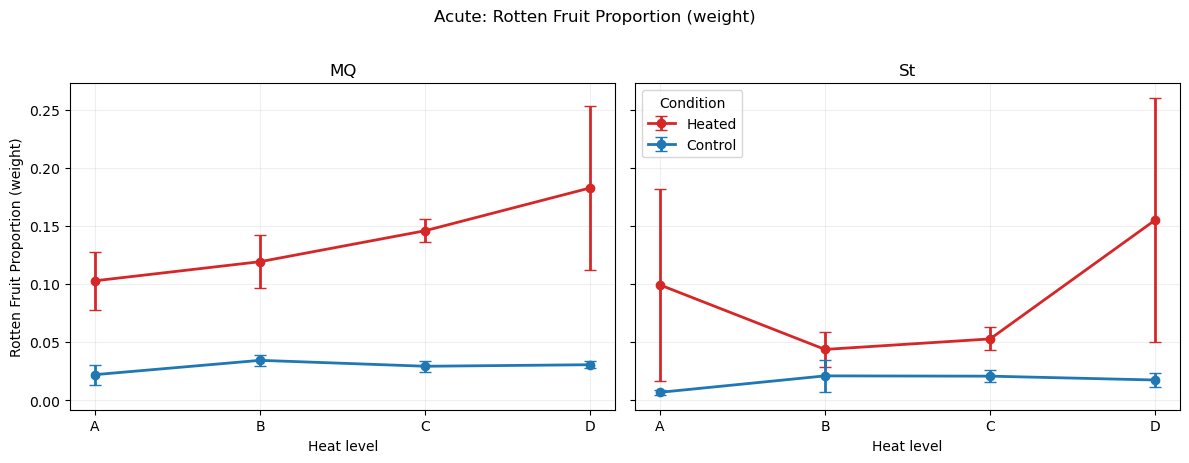

In [9]:
def plot_acute_mean_se(outcome: str, filename: str):
    summary = mean_se_frame(acute_keep, ['cultivar', 'heat_level', 'is_control'], outcome)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, cultivar in zip(axes, CULTIVAR_ORDER):
        sub = summary[summary['cultivar'] == cultivar].copy()
        for is_control in ACUTE_CONDITION_ORDER:
            curve = sub[sub['is_control'] == is_control].copy()
            curve['heat_level'] = pd.Categorical(curve['heat_level'], categories=HEAT_LEVEL_ORDER, ordered=True)
            curve = curve.sort_values('heat_level')
            x = np.arange(len(curve))
            ax.errorbar(
                x,
                curve['mean'],
                yerr=curve['se'],
                marker='o',
                linewidth=2,
                capsize=4,
                color=CONDITION_COLORS[is_control],
                label=CONDITION_LABELS[is_control],
            )
        ax.set_xticks(np.arange(len(HEAT_LEVEL_ORDER)))
        ax.set_xticklabels(HEAT_LEVEL_ORDER)
        ax.set_xlabel('Heat level')
        ax.set_title(f'{cultivar}')
        ax.grid(alpha=0.2)
    axes[0].set_ylabel(OUTCOME_LABELS[outcome])
    axes[1].legend(title='Condition', loc='best')
    fig.suptitle(f'Acute: {OUTCOME_LABELS[outcome]}', y=1.02)
    fig.tight_layout()
    fig_path = FIG_DIR / filename
    fig.savefig(fig_path, dpi=180, bbox_inches='tight')
    plt.show()
    return fig_path

fig_ac_hw = plot_acute_mean_se('healthy_weight_g', 'yield_acute_healthy_weight_mean_se.png')
fig_ac_rc = plot_acute_mean_se('pct_rotten_count', 'yield_acute_rotten_count_mean_se.png')
fig_ac_rw = plot_acute_mean_se('pct_rotten_weight', 'yield_acute_rotten_weight_mean_se.png')


## 6) Acute models and ANOVA-style tests

In [10]:
acute_models = {}
acute_wald_tables = []
for outcome in OUTCOMES:
    model, optimizer = fit_mixedlm(f'{outcome} ~ C(cultivar) * C(heat_level) * C(is_control)', acute_keep, 'pair_id')
    acute_models[outcome] = model
    table = mixedlm_wald_terms_table(model, outcome)
    table.insert(0, 'optimizer', optimizer)
    acute_wald_tables.append(table)

acute_wald = pd.concat(acute_wald_tables, ignore_index=True)
print('Acute Wald term tests (Python analogue of ANOVA)')
display(acute_wald)


Acute Wald term tests (Python analogue of ANOVA)


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn

,optimizer,outcome,term,statistic,df_constraint,p_value
0,lbfgs,healthy_weight_g,Intercept,120.210488,1.0,5.689216e-28
1,lbfgs,healthy_weight_g,C(cultivar),0.110596,1.0,7.394665e-01
2,lbfgs,healthy_weight_g,C(heat_level),3.238708,3.0,3.562649e-01
3,lbfgs,healthy_weight_g,C(is_control),5.059529,1.0,2.449089e-02
4,lbfgs,healthy_weight_g,C(cultivar):C(heat_level),2.486318,3.0,4.777688e-01
5,lbfgs,healthy_weight_g,C(cultivar):C(is_control),0.496310,1.0,4.811260e-01
6,lbfgs,healthy_weight_g,C(heat_level):C(is_control),0.855062,3.0,8.362567e-01
7,lbfgs,healthy_weight_g,C(cultivar):C(heat_level):C(is_control),3.098351,3.0,3.767086e-01
8,lbfgs,pct_rotten_count,Intercept,19.441427,1.0,1.037324e-05
9,lbfgs,pct_rotten_count,C(cultivar),0.172755,1.0,6.776747e-01


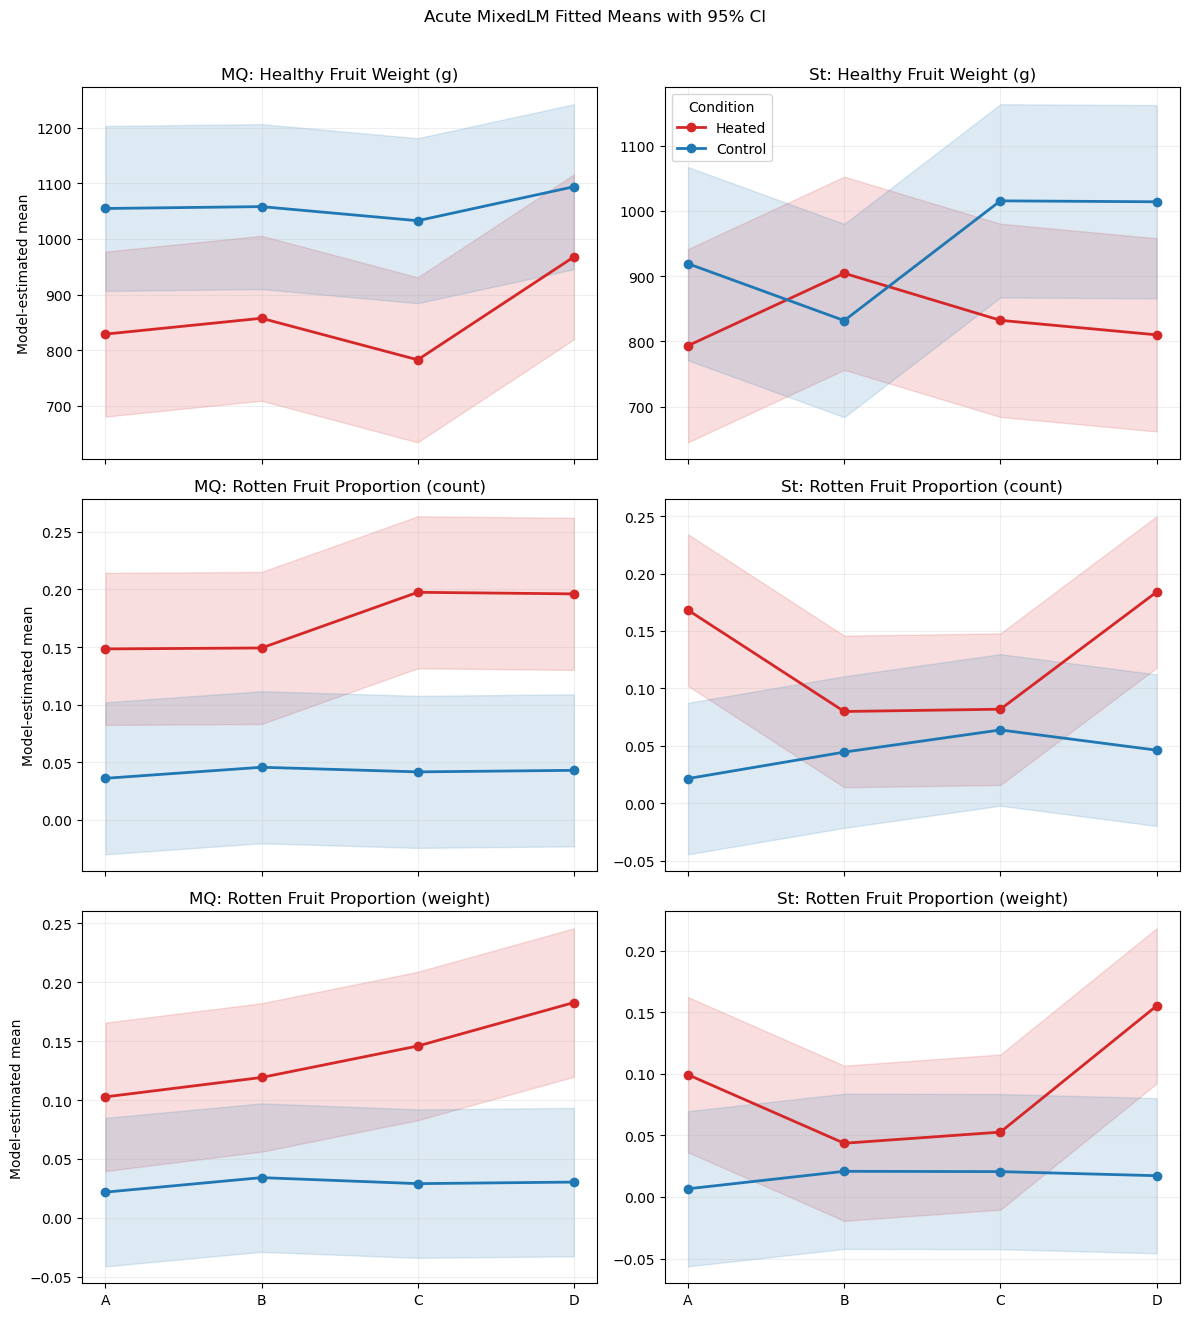

In [11]:
acute_grid = pd.DataFrame(
    [
        {
            'cultivar': cultivar,
            'heat_level': heat_level,
            'is_control': is_control,
            'outcome': outcome,
        }
        for outcome in OUTCOMES
        for cultivar in CULTIVAR_ORDER
        for heat_level in HEAT_LEVEL_ORDER
        for is_control in ACUTE_CONDITION_ORDER
    ]
)

acute_pred_frames = []
for outcome in OUTCOMES:
    grid = acute_grid[acute_grid['outcome'] == outcome][['cultivar', 'heat_level', 'is_control']].copy()
    pred = fixed_effect_predictions(acute_models[outcome], grid)
    pred['outcome'] = outcome
    acute_pred_frames.append(pred)
acute_pred = pd.concat(acute_pred_frames, ignore_index=True)

fig_ac_pred, axes = plt.subplots(3, 2, figsize=(12, 13), sharex=True)
for row, outcome in enumerate(OUTCOMES):
    for col, cultivar in enumerate(CULTIVAR_ORDER):
        ax = axes[row, col]
        sub = acute_pred[(acute_pred['outcome'] == outcome) & (acute_pred['cultivar'] == cultivar)].copy()
        for is_control in ACUTE_CONDITION_ORDER:
            curve = sub[sub['is_control'] == is_control].copy()
            curve['heat_level'] = pd.Categorical(curve['heat_level'], categories=HEAT_LEVEL_ORDER, ordered=True)
            curve = curve.sort_values('heat_level')
            x = np.arange(len(curve))
            ax.plot(x, curve['pred'], marker='o', linewidth=2, color=CONDITION_COLORS[is_control], label=CONDITION_LABELS[is_control])
            ax.fill_between(x, curve['ci_low'], curve['ci_high'], color=CONDITION_COLORS[is_control], alpha=0.15)
        ax.set_xticks(np.arange(len(HEAT_LEVEL_ORDER)))
        ax.set_xticklabels(HEAT_LEVEL_ORDER)
        ax.set_title(f'{cultivar}: {OUTCOME_LABELS[outcome]}')
        ax.grid(alpha=0.2)
        if col == 0:
            ax.set_ylabel('Model-estimated mean')
        if row == 0 and col == 1:
            ax.legend(title='Condition', loc='upper left')
fig_ac_pred.suptitle('Acute MixedLM Fitted Means with 95% CI', y=1.01)
fig_ac_pred.tight_layout()
fig_ac_pred_path = FIG_DIR / 'yield_acute_mixedlm_fitted_means.png'
fig_ac_pred.savefig(fig_ac_pred_path, dpi=180, bbox_inches='tight')
plt.show()


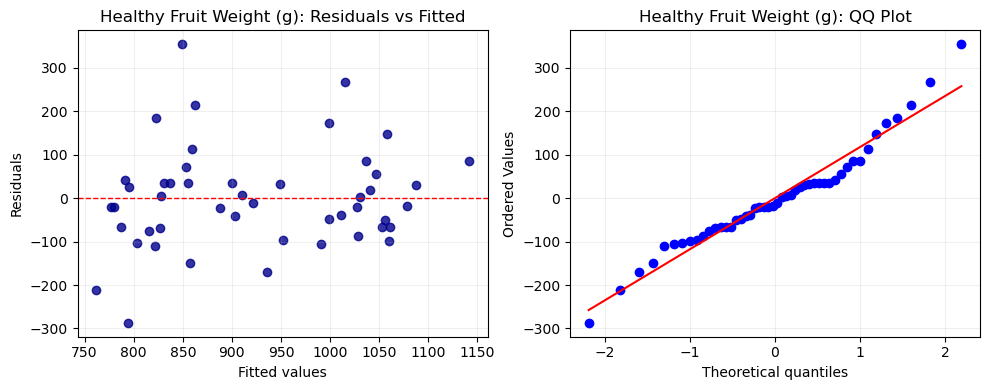

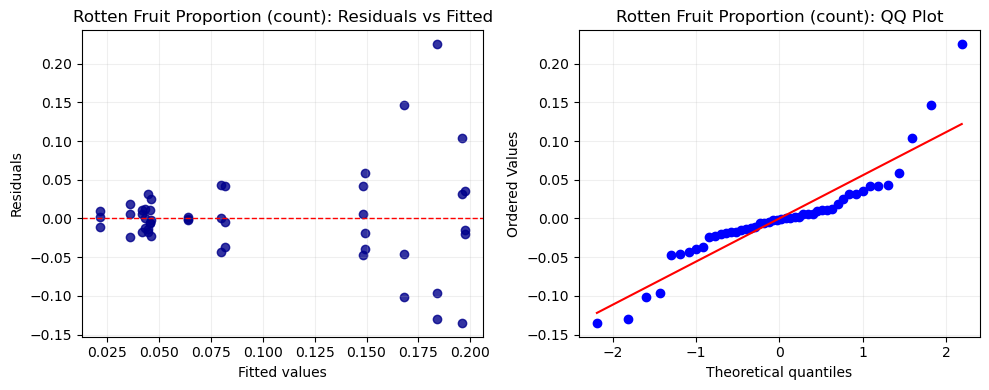

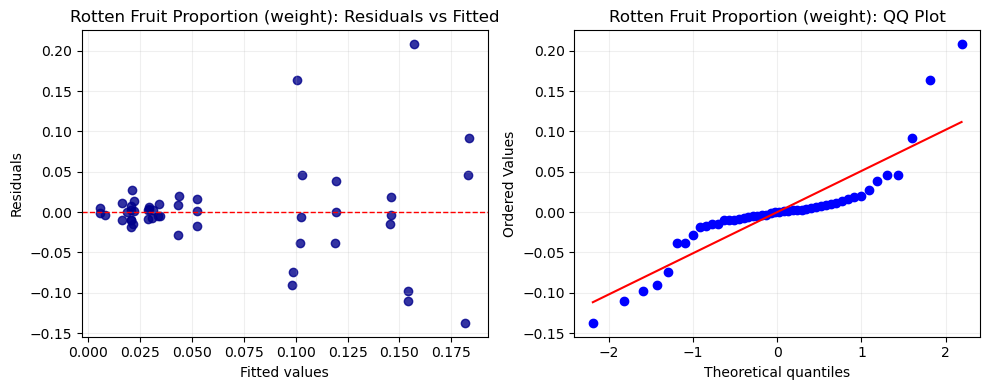

In [12]:
diag_paths_acute = []
for outcome in OUTCOMES:
    title = OUTCOME_LABELS[outcome]
    fig = diagnostic_figure(acute_models[outcome], title)
    out_path = FIG_DIR / f'yield_acute_diagnostics_{outcome}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    diag_paths_acute.append(out_path)
    plt.show()


## 7) Saved outputs

In [13]:
saved_paths = [
    fig_dist_path,
    fig_lt_hw,
    fig_lt_rc,
    fig_lt_rw,
    fig_lt_pred_path,
    *diag_paths_lt,
    fig_ac_hw,
    fig_ac_rc,
    fig_ac_rw,
    fig_ac_pred_path,
    *diag_paths_acute,
]

print('Saved figures:')
for p in saved_paths:
    print('-', relpath(p))


Saved figures:
- results/yield/figures/yield_longterm_distributions.png
- results/yield/figures/yield_longterm_healthy_weight_mean_se.png
- results/yield/figures/yield_longterm_rotten_count_mean_se.png
- results/yield/figures/yield_longterm_rotten_weight_mean_se.png
- results/yield/figures/yield_longterm_mixedlm_fitted_means.png
- results/yield/figures/yield_longterm_diagnostics_healthy_weight_g.png
- results/yield/figures/yield_longterm_diagnostics_pct_rotten_count.png
- results/yield/figures/yield_longterm_diagnostics_pct_rotten_weight.png
- results/yield/figures/yield_acute_healthy_weight_mean_se.png
- results/yield/figures/yield_acute_rotten_count_mean_se.png
- results/yield/figures/yield_acute_rotten_weight_mean_se.png
- results/yield/figures/yield_acute_mixedlm_fitted_means.png
- results/yield/figures/yield_acute_diagnostics_healthy_weight_g.png
- results/yield/figures/yield_acute_diagnostics_pct_rotten_count.png
- results/yield/figures/yield_acute_diagnostics_pct_rotten_weight.p